# Titanic Survival Prediction using Machine Learning

The Titanic dataset includes details about passengers such as their personal background and travel-related information from the RMS Titanic. The aim of this project is to develop a machine learning classification model to predict whether a passenger survived the disaster.

Output variable is survived,where:

0 indicates Passenger did not survived

1 indicates Passenger survived

# Part A :- Data Loading and Exploration

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Explanation:

We import Pandas for data manipulation, NumPy for numerical operations, and Matplotlib / Seaborn for visualization.

#### Data Loading



In [193]:
data_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(data_url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Explanation:

The dataset is loaded directly from the github link provided in the pdf.

#### Dataset Shape

In [194]:
df.shape

(891, 12)

Explanation:

The dataset contains 891 rows (passengers) and 12 columns (features).


#### Data Types

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Explanation:

This step helps us understand the data types of each feature, which is important for preprocessing and model training.

#### Missing Values

In [196]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Explanation:

Missing values are present in Age, Cabin, and Embarked columns. We need to handle them during preprocessing.

#### Summary Statistics

In [197]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Explanation:

Summary statistics help understand the distribution of numerical variables like Age and Fare.

# Part B :- Data Preprocessing and Feature Engineering


#### Handle missing values

In [198]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)

Explanation:

Age → Missing values in the Age column are filled using the median because age is a numerical feature and the median is less affected by outliers compared to the mean.

Embarked → filled with most frequent value.

Cabin → dropped because most values are missing.

#### Encode Categorical Variables

In [199]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

Explanation:

Machine learning models require numerical input, so categorical variables must be encoded.

In [200]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

FamilySize was created to combine siblings or spouses and parents or children into one feature, because family presence may influence survival chances.

In [201]:
df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


#### Remove Irrelevant Columns

In [202]:
df.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

Explanation:

These columns do not contribute meaningful predictive information.

# Part C :- Data Visualization

#### Survival count

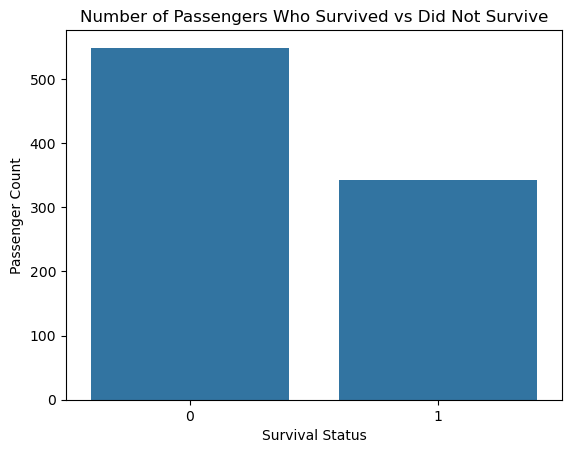

In [203]:
sns.countplot(x='Survived', data=df)
plt.title("Number of Passengers Who Survived vs Did Not Survive")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")
plt.show()

Insight from the chart: More passengers did not survive than survived.

#### Survival by Gender

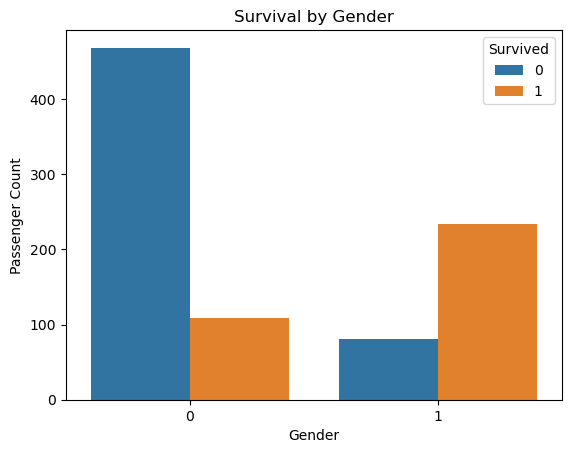

In [204]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")
plt.legend(title="Survived")
plt.show()

Insight from chart: Females had a significantly higher survival rate than males.

#### Age Distribution

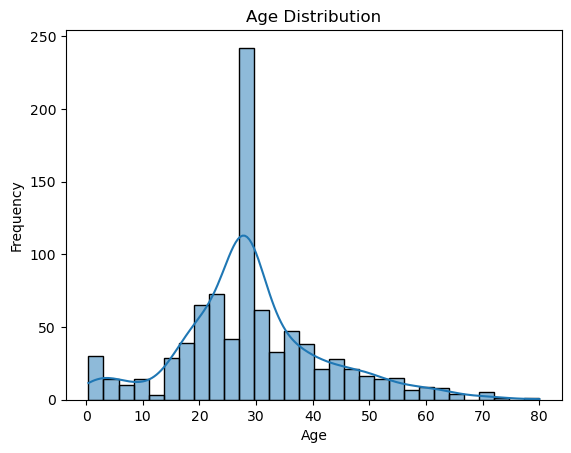

In [205]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Insight from chart: Most passengers were young adults between 20–40 years.

# PART D :- Model Building

#### Separating Features and Target

In [206]:
X = df.drop('Survived', axis=1)
y = df['Survived']

Train-Test Split

In [207]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Train Model

Logistic Regression is used here as it is good for binary classification.

In [208]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Explanation:

Logistic Regression is suitable for binary classification problems like survival prediction.

#### Comparison Model

In [209]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


A Decision Tree model was also tested to compare performance with Logistic Regression.

# PART E :- Model Evaluation

#### Predictions

In [210]:
y_pred = model.predict(X_test)

Accuracy Score

In [211]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8100558659217877

#### Confusion Matrix

In [212]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[90, 15],
       [19, 55]])

Precision, recall, F1-score for logistic regression

In [213]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### Explanation and output:

1)True Positive

2)True Negative

3)False Positive

4)False Negative

90 True Negatives (TN) → correctly predicted passengers who did not survive

55 True Positives (TP) → correctly predicted passengers who survived

15 False Positives (FP) → predicted survived but actually died

19 False Negatives (FN) → predicted died but actually survived

Predictions for Decision Tree

In [214]:
dt_pred = dt.predict(X_test)

Precision, recall, F1-score for Decision Trees

#### Accuracy for Decision Tree

In [215]:
print("Decision Tree Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [216]:
accuracy_score(y_test, dt_pred)

0.7877094972067039

# PART F :- Result Interpretation

Model Performance:

The model achieved an accuracy of approximately 81%, indicating reasonably good predictive performance. A Decision Tree model was also tested, which produced an accuracy of 78%, therefore Logistic Regression was selected as the primary model for this project. The confusion matrix shows that the model correctly predicted 90 passengers who did not survive (True Negatives) and 55 passengers who survived (True Positives). However, 15 passengers were incorrectly predicted as survivors (False Positives) and 19 survivors were predicted as non-survivors (False Negatives).

#### Errors

Two types of errors occur:

False Positives → predicted survival but passenger died

False Negatives → predicted death but passenger survived

False negatives are particularly important as the model fails to identify some passengers who actually survived.

#### Reasons for Misclassification:

Missing or incomplete passenger data

Limited features in dataset

Model simplicity

#### Limitations:

Dataset size is relatively small

Some important features like lifeboat access are missing

#### Improvements:

Try more advanced models such as Random Forest or Gradient Boosting

Perform feature engineering

Apply cross-validation and hyperparameter tuning

### Final Conclusion:-

This project successfully applied machine learning techniques to predict the survival of passengers on the Titanic. After performing data preprocessing, exploratory data analysis, visualization, and model building, the Logistic Regression model achieved an accuracy of approximately 81%, showing satisfactory predictive performance. The analysis revealed that important features such as gender, passenger class, and fare had a significant impact on survival. Overall, the project demonstrates the effective use of machine learning in solving a real-world classification problem and provides valuable insights from the Titanic dataset.